# Model Evaluation & Visualization
This notebook loads the trained Convolutional Autoencoder and visualizes its anomaly maps on test images with actual defects.

In [1]:
import os
import yaml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import sys

# Add src directory to path
sys.path.append('../src')

from data.dataset import MVTecVialDataset
from preprocessing.transforms import get_transforms
from models.autoencoder import ConvAutoencoder
from visualization.visualize import plot_anomaly_map

In [2]:
# Load configuration
with open("../configs/default.yaml", "r") as f:
    config = yaml.safe_load(f)

device = torch.device(config["training"]["device"] if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
# Setup data
transform, target_transform = get_transforms(image_size=tuple(config["data"]["image_size"]))
dataset_path = "../" + config["data"]["dataset_path"]

# Load the test dataset (which contains the anomalies/defects)
test_dataset = MVTecVialDataset(
    root_dir=dataset_path, 
    split="test_public", 
    transform=transform,
    target_transform=target_transform
)

# Set num_workers=0 to prevent multiprocessing errors on Windows
test_loader = DataLoader(
    test_dataset, 
    batch_size=1, # Process one image at a time for visualization
    shuffle=True, # Shuffle to see different images each time
    num_workers=0
)

In [4]:
# Setup model and load trained weights
model = ConvAutoencoder(
    in_channels=config["model"]["in_channels"], 
    latent_dim=config["model"]["latent_dim"]
).to(device)

model_path = os.path.join("../", config["training"]["save_dir"], "best_model.pth")
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print("Model loaded successfully!")

Model loaded successfully!


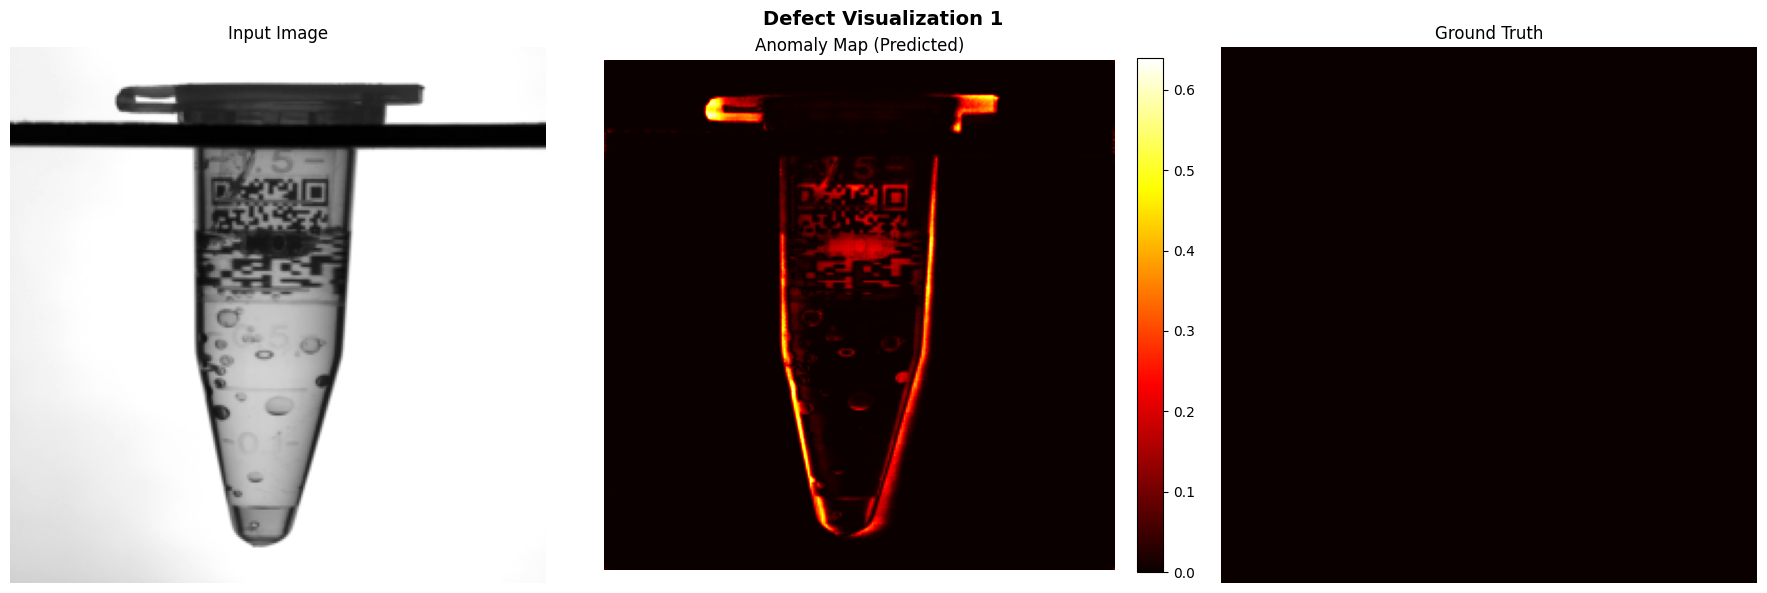

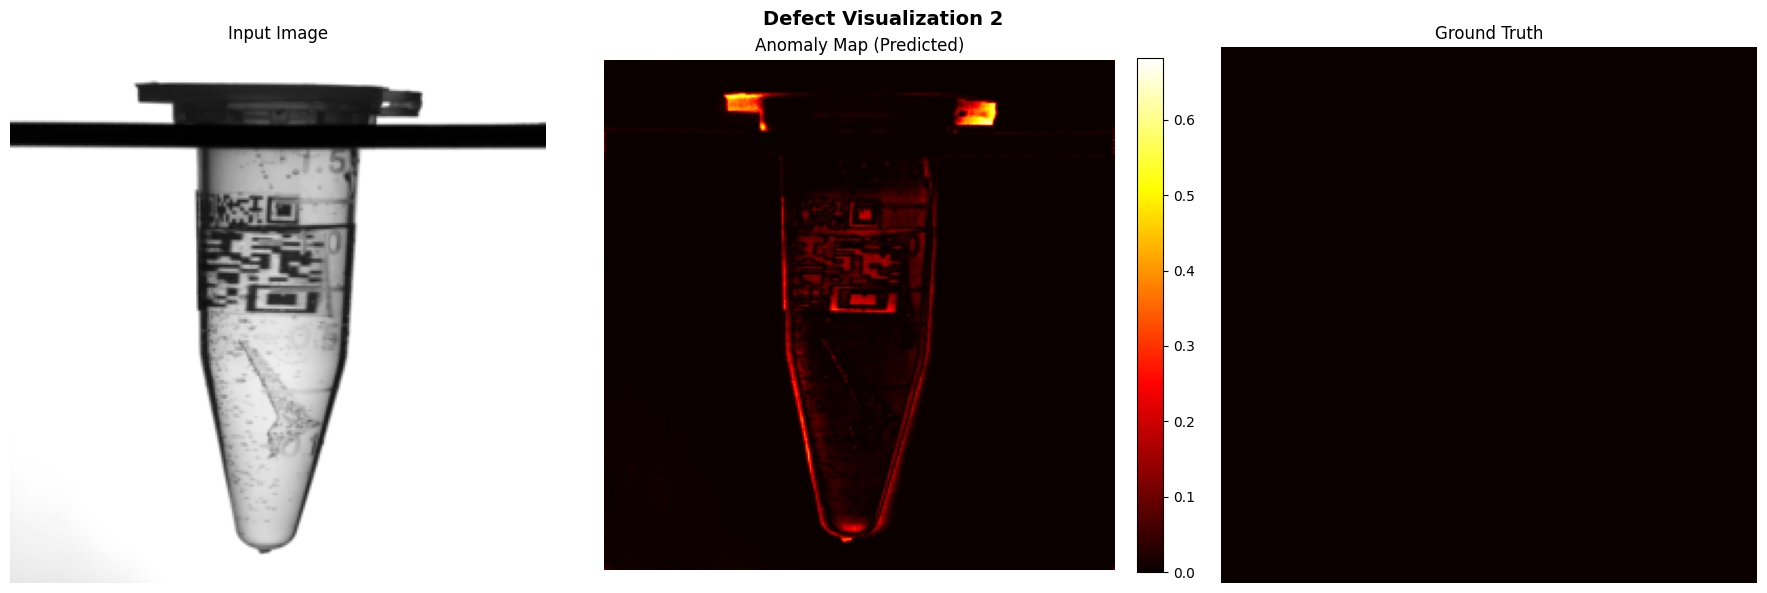

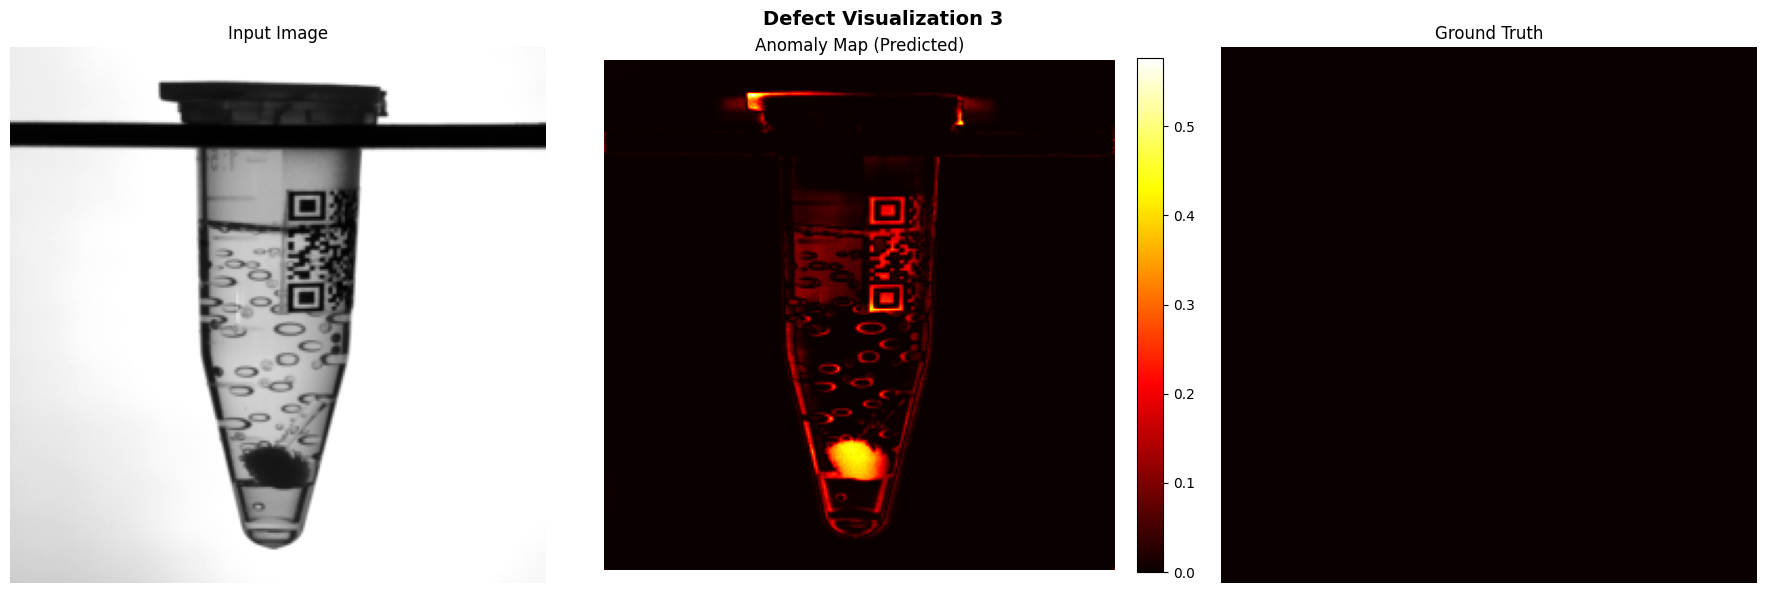

In [5]:
# Visualization Loop
num_samples = 3
samples_shown = 0
criterion = nn.MSELoss(reduction='none')

with torch.no_grad():
    for images, labels, masks in test_loader:
        # We only want to visualize anomalous images (label == 1)
        if labels.item() == 0:
            continue
            
        images = images.to(device)
        outputs = model(images)
        
        # Calculate per-pixel reconstruction error (MSE)
        mse = criterion(outputs, images)
        
        # Prepare tensors for plotting (remove batch/channel dimensions)
        input_img = images.squeeze().cpu().numpy()
        anomaly_map = mse.mean(dim=1).squeeze().cpu().numpy() # Average error across channels if any
        ground_truth_mask = masks.squeeze().cpu().numpy() if masks is not None else None
        
        # Use the utility function to plot the heatmaps
        plot_anomaly_map(
            image=input_img, 
            anomaly_map=anomaly_map, 
            mask=ground_truth_mask, 
            title=f"Defect Visualization {samples_shown + 1}",
            show=True
        )
        
        samples_shown += 1
        if samples_shown >= num_samples:
            break